# 1. Data exploration

What the fleet looks like, which sensors carry signal, and what the target
actually is. Every helper called here lives in `src/predmaint/`, so nothing in
this notebook has to be re-implemented to ship.

Prerequisite: `make data` (real dataset) or `make demo-data` (synthetic stand-in).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import plotly.io as pio

# Static images: GitHub does not render interactive Plotly output in notebooks.
pio.renderers.default = "png"

from predmaint.config import RUL_COL, SENSOR_COLS, UNIT_COL
from predmaint.data.loader import load_subset
from predmaint.features.build import drop_dead_sensors
from predmaint.viz.plots import sensor_degradation

train, test = load_subset("FD001")
train.shape, test.shape

((20631, 27), (13096, 27))

## Fleet shape

Each engine is one run-to-failure trajectory. Lifetimes vary a lot, which is why
the model is never allowed to see an engine in both train and validation.

In [2]:
lifetimes = train.groupby(UNIT_COL)["cycle"].max()
pd.DataFrame(
    {
        "engines": [train[UNIT_COL].nunique()],
        "rows": [len(train)],
        "shortest life": [lifetimes.min()],
        "median life": [lifetimes.median()],
        "longest life": [lifetimes.max()],
    }
)

,engines,rows,shortest life,median life,longest life
0,100,20631,128,199.0,362


## Which sensors carry signal

Several channels are constant across the whole fleet. They cost features and
buy nothing, so a variance filter fitted on the training set removes them.

In [3]:
kept = drop_dead_sensors(train)
dropped = sorted(set(SENSOR_COLS) - set(kept))
print(f"kept {len(kept)} sensors, dropped {len(dropped)}: {dropped}")
train[kept].describe().T[["mean", "std", "min", "max"]].head(10)

kept 15 sensors, dropped 6: ['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5']


,mean,std,min,max
sensor_2,642.680934,0.500053,641.21,644.53
sensor_3,1590.523119,6.131150,1571.04,1616.91
sensor_4,1408.933782,9.000605,1382.25,1441.49
sensor_6,21.609803,0.001389,21.60,21.61
sensor_7,553.367711,0.885092,549.85,556.06
sensor_8,2388.096652,0.070985,2387.90,2388.56
sensor_9,9065.242941,22.082880,9021.73,9244.59
sensor_11,47.541168,0.267087,46.85,48.53
sensor_12,521.413470,0.737553,518.69,523.38
sensor_13,2388.096152,0.071919,2387.88,2388.56


## Degradation is visible

This is the whole premise of the project: engines run flat for hundreds of
cycles, then drift. A model that only sees a snapshot cannot tell those two
regimes apart, which is why the feature set encodes trend.

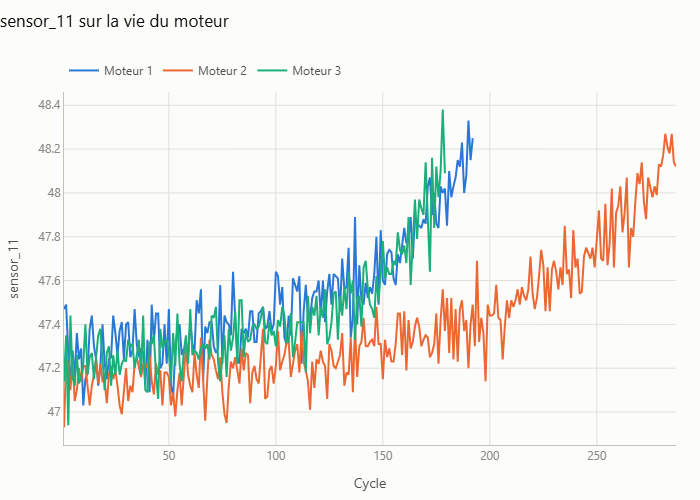

In [4]:
focus = kept[len(kept) // 2]
sensor_degradation(train, focus)

## The target

RUL counts down to zero at failure. Above roughly 125 cycles the sensors are
flat, so the raw target asks the model to predict something the data does not
contain. Clipping makes the problem well posed.

In [5]:
train[RUL_COL].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul, dtype: float64